# Estudo de Seleção de Atributos no Medical Cost

## Teste de Ablação com Random Forest, Regressão Linear, Ridge e Lasso

Este notebook implementa um **teste de ablação** para analisar se é possível simplificar o modelo de previsão de `charges` sem comprometer excessivamente o desempenho.

### Objetivo

Comparar seis cenários de atributos e modelo usando o mesmo pipeline de pré-processamento:

- **Cenário A:** Random Forest com todas as variáveis disponíveis
- **Cenário B:** Random Forest com apenas `smoker`, `age` e `bmi`
- **Cenário C:** Regressão Linear com todas as variáveis disponíveis
- **Cenário D:** Regressão Linear com apenas `smoker`, `age` e `bmi`
- **Cenário E:** Ridge com todas as variáveis disponíveis
- **Cenário F:** Lasso com todas as variáveis disponíveis

### Estratégia experimental

Cada cenário será avaliado de forma independente com **Repeated K-Fold (10 folds, 5 repetições)**. Ao final, vamos comparar:

- `MAE pooled`
- `R2 pooled`
- `Tempo de Execução`

Além disso, um boxplot do `MAE` permitirá verificar se a remoção das variáveis mais fracas reduziu a variabilidade dos erros entre os folds e se essa perda de desempenho é semelhante nos diferentes modelos lineares e não lineares.


In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)


## 1. Configuração e carregamento

As funções abaixo reaproveitam a lógica base do notebook de Random Forest para localizar e carregar o dataset de forma robusta.


In [2]:
RANDOM_STATE = 42
TARGET = "charges"


def locate_dataset(filename: str = "insurance.csv") -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "trabalho" / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Não foi possível localizar {filename}. Verifique a pasta data/."
    )


DATA_PATH = locate_dataset()
DATA_PATH


WindowsPath('c:/Users/rodri/Documents/2semestre/AC/trabalho/data/insurance.csv')

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    expected_columns = {"age", "sex", "bmi", "children", "smoker", "region", TARGET}
    missing_columns = expected_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltam colunas esperadas: {missing_columns}")
    return df


df = load_data(DATA_PATH)
display(df.head())
print(f"Dimensão do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.isna().sum().rename("missing_values").to_frame())


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


Dimensão do dataset: 1338 linhas x 7 colunas


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 2. Pipeline de pré-processamento e modelo

O pipeline abaixo mantém o mesmo princípio metodológico do notebook de Random Forest:

- imputação dentro de cada fold;
- transformação categórica com `OneHotEncoder`;
- escalonamento das variáveis numéricas com `StandardScaler`;
- modelo final com `RandomForestRegressor`, `LinearRegression`, `RidgeCV` ou `LassoCV`.

Isso garante que a comparação entre cenários não sofre de *data leakage* e que todos os modelos passam pelo mesmo fluxo de pré-processamento.


In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(
    numeric_features: list[str],
    categorical_features: list[str],
    model_type: str = "rf",
) -> Pipeline:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

    if model_type == "rf":
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    elif model_type == "lr":
        model = LinearRegression()
    elif model_type == "ridge":
        model = RidgeCV(alphas=np.logspace(-3, 3, 25))
    elif model_type == "lasso":
        model = LassoCV(
            alphas=np.logspace(-3, 1, 25),
            cv=5,
            random_state=RANDOM_STATE,
            max_iter=10000,
        )
    else:
        raise ValueError("model_type deve ser 'rf', 'lr', 'ridge' ou 'lasso'.")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


## 3. Funções auxiliares para o teste de ablação

Estas funções executam o `Repeated K-Fold (10x5)` para cada cenário, armazenando:

- métricas por iteração;
- métricas agregadas (*pooled*);
- tempo total de execução.

Todos os cenários passam pelo mesmo processo de escalonamento e validação, permitindo comparar a perda de desempenho ao reduzir atributos e a diferença entre modelos clássicos, regularizados e não lineares.


In [5]:
def compute_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
    }


def get_model_label(model_type: str) -> str:
    mapping = {
        "rf": "Random Forest",
        "lr": "Regressão Linear",
        "ridge": "Ridge",
        "lasso": "Lasso",
    }
    return mapping[model_type]


def evaluate_repeated_kfold_scenario(
    df: pd.DataFrame,
    feature_set: list[str],
    numeric_features: list[str],
    categorical_features: list[str],
    scenario_name: str,
    model_type: str,
) -> tuple[pd.DataFrame, dict]:
    X = df[feature_set].copy()
    y = df[TARGET].copy()

    cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE)
    base_estimator = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type=model_type,
    )

    split_rows = []
    pooled_truth = []
    pooled_pred = []

    start_time = time.time()

    for iteration, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        model = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pooled_truth.extend(y_test.to_numpy())
        pooled_pred.extend(np.asarray(y_pred))

        row = compute_metrics(y_test, y_pred)
        row["Scenario"] = scenario_name
        row["Model"] = get_model_label(model_type)
        row["Iteration"] = iteration
        split_rows.append(row)

    elapsed = time.time() - start_time

    split_df = pd.DataFrame(split_rows)
    pooled_metrics = compute_metrics(np.array(pooled_truth), np.array(pooled_pred))
    pooled_metrics["Scenario"] = scenario_name
    pooled_metrics["Model"] = get_model_label(model_type)
    pooled_metrics["ExecutionTimeSeconds"] = elapsed

    return split_df, pooled_metrics


def run_ablation_experiment(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    scenarios = {
        "Cenário A (Random Forest - Todas as variáveis)": {
            "features": ["age", "sex", "bmi", "children", "smoker", "region"],
            "numeric": ["age", "bmi", "children"],
            "categorical": ["sex", "smoker", "region"],
            "model_type": "rf",
        },
        "Cenário B (Random Forest - smoker, age, bmi)": {
            "features": ["smoker", "age", "bmi"],
            "numeric": ["age", "bmi"],
            "categorical": ["smoker"],
            "model_type": "rf",
        },
        "Cenário C (Regressão Linear - Todas as variáveis)": {
            "features": ["age", "sex", "bmi", "children", "smoker", "region"],
            "numeric": ["age", "bmi", "children"],
            "categorical": ["sex", "smoker", "region"],
            "model_type": "lr",
        },
        "Cenário D (Regressão Linear - smoker, age, bmi)": {
            "features": ["smoker", "age", "bmi"],
            "numeric": ["age", "bmi"],
            "categorical": ["smoker"],
            "model_type": "lr",
        },
        "Cenário E (Ridge - Todas as variáveis)": {
            "features": ["age", "sex", "bmi", "children", "smoker", "region"],
            "numeric": ["age", "bmi", "children"],
            "categorical": ["sex", "smoker", "region"],
            "model_type": "ridge",
        },
        "Cenário F (Lasso - Todas as variáveis)": {
            "features": ["age", "sex", "bmi", "children", "smoker", "region"],
            "numeric": ["age", "bmi", "children"],
            "categorical": ["sex", "smoker", "region"],
            "model_type": "lasso",
        },
    }

    split_results = []
    pooled_results = []

    for scenario_name, config in scenarios.items():
        split_df, pooled_metrics = evaluate_repeated_kfold_scenario(
            df=df,
            feature_set=config["features"],
            numeric_features=config["numeric"],
            categorical_features=config["categorical"],
            scenario_name=scenario_name,
            model_type=config["model_type"],
        )
        print(
            f"{scenario_name} concluído em "
            f"{pooled_metrics['ExecutionTimeSeconds']:.2f} s"
        )
        split_results.append(split_df)
        pooled_results.append(pooled_metrics)

    return pd.concat(split_results, ignore_index=True), pd.DataFrame(pooled_results)


def extract_lasso_coefficients(df: pd.DataFrame) -> pd.DataFrame:
    feature_set = ["age", "sex", "bmi", "children", "smoker", "region"]
    numeric_features = ["age", "bmi", "children"]
    categorical_features = ["sex", "smoker", "region"]

    X = df[feature_set].copy()
    y = df[TARGET].copy()

    lasso_pipeline = build_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        model_type="lasso",
    )
    lasso_pipeline.fit(X, y)

    preprocessor = lasso_pipeline.named_steps["preprocessor"]
    model = lasso_pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    cleaned_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

    coef_df = pd.DataFrame(
        {
            "Feature": cleaned_names,
            "Coefficient": model.coef_,
            "AbsCoefficient": np.abs(model.coef_),
        }
    ).sort_values("AbsCoefficient", ascending=False).reset_index(drop=True)

    alpha_value = getattr(model, "alpha_", np.nan)
    print(f"Melhor alpha encontrado pelo LassoCV: {alpha_value:.6f}")

    return coef_df


## 4. Execução dos cenários de ablação

Agora executamos os seis cenários de forma independente, sempre com `Repeated K-Fold (10x5)`.


In [6]:
split_results_ablation, pooled_results_ablation = run_ablation_experiment(df)

display(split_results_ablation.head())
display(pooled_results_ablation)


Cenário A (Random Forest - Todas as variáveis) concluído em 48.21 s
Cenário B (Random Forest - smoker, age, bmi) concluído em 33.19 s
Cenário C (Regressão Linear - Todas as variáveis) concluído em 1.72 s
Cenário D (Regressão Linear - smoker, age, bmi) concluído em 1.53 s
Cenário E (Ridge - Todas as variáveis) concluído em 2.03 s
Cenário F (Lasso - Todas as variáveis) concluído em 3.52 s


,MAE,RMSE,R2,Scenario,Model,Iteration
0,"2,517.8152","4,717.7564",0.8387,Cenário A (Random Forest - Todas as variáveis),Random Forest,1
1,"2,579.6432","4,691.9272",0.8724,Cenário A (Random Forest - Todas as variáveis),Random Forest,2
2,"2,509.5617","4,482.8496",0.8447,Cenário A (Random Forest - Todas as variáveis),Random Forest,3
3,"2,858.2297","5,209.4101",0.8263,Cenário A (Random Forest - Todas as variáveis),Random Forest,4
4,"2,777.5780","4,323.5957",0.8963,Cenário A (Random Forest - Todas as variáveis),Random Forest,5


,MAE,RMSE,R2,Scenario,Model,ExecutionTimeSeconds
0,"2,653.9076","4,834.6341",0.8405,Cenário A (Random Forest - Todas as variáveis),Random Forest,48.2078
1,"2,923.6665","5,254.4210",0.8116,"Cenário B (Random Forest - smoker, age, bmi)",Random Forest,33.1867
2,"4,203.7421","6,088.7246",0.7470,Cenário C (Regressão Linear - Todas as variáveis),Regressão Linear,1.7243
3,"4,232.5339","6,107.8885",0.7454,"Cenário D (Regressão Linear - smoker, age, bmi)",Regressão Linear,1.5333
4,"4,207.5918","6,088.6541",0.7470,Cenário E (Ridge - Todas as variáveis),Ridge,2.0274
5,"4,203.7929","6,088.7480",0.7470,Cenário F (Lasso - Todas as variáveis),Lasso,3.5167


## 5. Tabela comparativa final

A tabela `df_comparativo_atributos` resume o trade-off entre:

- qualidade preditiva (`MAE pooled` e `R2 pooled`);
- custo computacional (`Tempo de Execução`);
- impacto da remoção de atributos e da regularização em diferentes famílias de modelo.


In [7]:
df_comparativo_atributos = pooled_results_ablation[
    ["Scenario", "Model", "MAE", "R2", "ExecutionTimeSeconds"]
].rename(
    columns={
        "Scenario": "Cenário",
        "Model": "Modelo",
        "MAE": "MAE pooled",
        "R2": "R2 pooled",
        "ExecutionTimeSeconds": "Tempo de Execução (s)",
    }
).sort_values("MAE pooled").reset_index(drop=True)

display(df_comparativo_atributos)


,Cenário,Modelo,MAE pooled,R2 pooled,Tempo de Execução (s)
0,Cenário A (Random Forest - Todas as variáveis),Random Forest,"2,653.9076",0.8405,48.2078
1,"Cenário B (Random Forest - smoker, age, bmi)",Random Forest,"2,923.6665",0.8116,33.1867
2,Cenário C (Regressão Linear - Todas as variáveis),Regressão Linear,"4,203.7421",0.7470,1.7243
3,Cenário F (Lasso - Todas as variáveis),Lasso,"4,203.7929",0.7470,3.5167
4,Cenário E (Ridge - Todas as variáveis),Ridge,"4,207.5918",0.7470,2.0274
5,"Cenário D (Regressão Linear - smoker, age, bmi)",Regressão Linear,"4,232.5339",0.7454,1.5333


## 6. Boxplot comparativo do MAE

O boxplot abaixo compara os seis cenários simultaneamente para verificar se a remoção das variáveis mais fracas reduziu a variabilidade dos erros e como Ridge e Lasso se posicionam entre a Regressão Linear simples e o Random Forest.


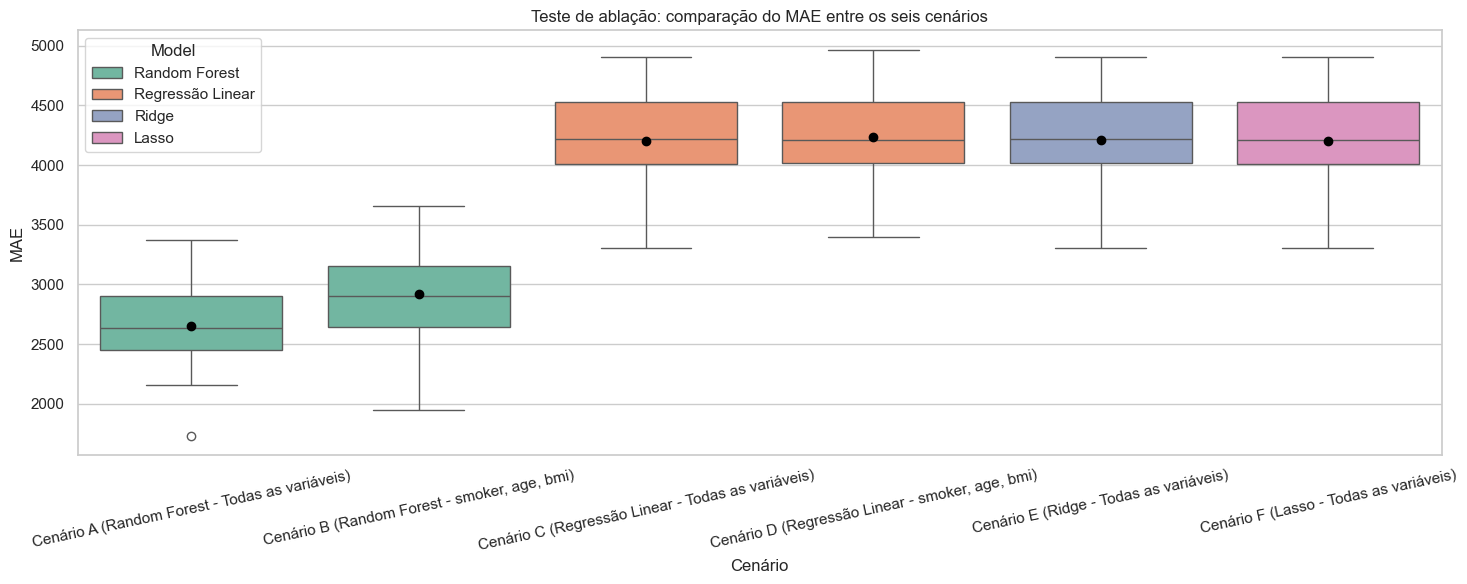

In [8]:
plt.figure(figsize=(15, 6))
ax = sns.boxplot(
    data=split_results_ablation,
    x="Scenario",
    y="MAE",
    hue="Model",
    dodge=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Teste de ablação: comparação do MAE entre os seis cenários")
ax.set_xlabel("Cenário")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 7. Análise dos coeficientes do Lasso

Como o Lasso aplica penalização `L1`, ele pode reduzir alguns coeficientes exatamente para zero. A tabela e o gráfico abaixo ajudam a verificar se atributos como `region` ou `sex` foram efetivamente descartados pelo modelo regularizado.


Melhor alpha encontrado pelo LassoCV: 10.000000


,Feature,Coefficient,AbsCoefficient
0,smoker_no,"-23,778.9979","23,778.9979"
1,age,"3,600.1039","3,600.1039"
2,bmi,"2,046.4956","2,046.4956"
3,region_northeast,815.4943,815.4943
4,children,563.5783,563.5783
5,region_northwest,461.8899,461.8899
6,region_southeast,-124.7855,124.7855
7,sex_female,86.1908,86.1908
8,region_southwest,-58.1917,58.1917
9,sex_male,-0.0000,0.0000


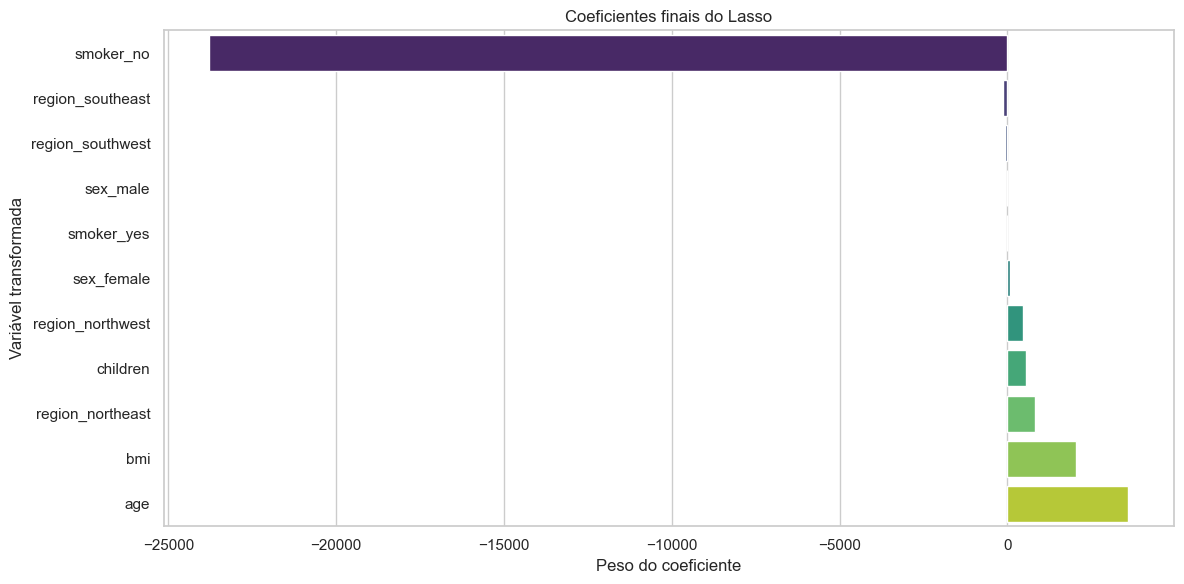

In [9]:
lasso_coef_df = extract_lasso_coefficients(df)
display(lasso_coef_df)

plt.figure(figsize=(12, 6))
plot_df = lasso_coef_df.sort_values("Coefficient")
ax = sns.barplot(
    data=plot_df,
    x="Coefficient",
    y="Feature",
    palette="viridis",
)
ax.set_title("Coeficientes finais do Lasso")
ax.set_xlabel("Peso do coeficiente")
ax.set_ylabel("Variável transformada")
plt.tight_layout()
plt.show()


## 9. Análise de Resíduos do Modelo Campeão (Random Forest - Cenário A)

Esta secção faz uma validação diagnóstica do modelo vencedor fora do protocolo de ablação. A ideia é verificar se os erros parecem ser apenas ruído aleatório ou se ainda existe algum padrão sistemático que o modelo não está a capturar.

Vamos:

- treinar o `RandomForestRegressor` com todas as variáveis;
- fazer um `train_test_split` de 80/20 apenas para esta visualização final;
- analisar os resíduos no conjunto de teste;
- inspecionar os maiores erros absolutos para perceber em que tipo de paciente o modelo falha mais.


In [10]:
all_features = ["age", "sex", "bmi", "children", "smoker", "region"]
numeric_features_all = ["age", "bmi", "children"]
categorical_features_all = ["sex", "smoker", "region"]

X_full = df[all_features].copy()
y_full = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

rf_champion = build_pipeline(
    numeric_features=numeric_features_all,
    categorical_features=categorical_features_all,
    model_type="rf",
)
rf_champion.fit(X_train, y_train)

y_pred_test = rf_champion.predict(X_test)
residuals = y_test - y_pred_test

residual_analysis_df = X_test.copy()
residual_analysis_df["y_real"] = y_test.values
residual_analysis_df["y_pred"] = y_pred_test
residual_analysis_df["residual"] = residuals.values
residual_analysis_df["abs_residual"] = residual_analysis_df["residual"].abs()

print("Métricas no conjunto de teste da análise de resíduos:")
display(pd.DataFrame([compute_metrics(y_test, y_pred_test)]))


Métricas no conjunto de teste da análise de resíduos:


,MAE,RMSE,R2
0,"2,541.6146","4,582.9726",0.8647


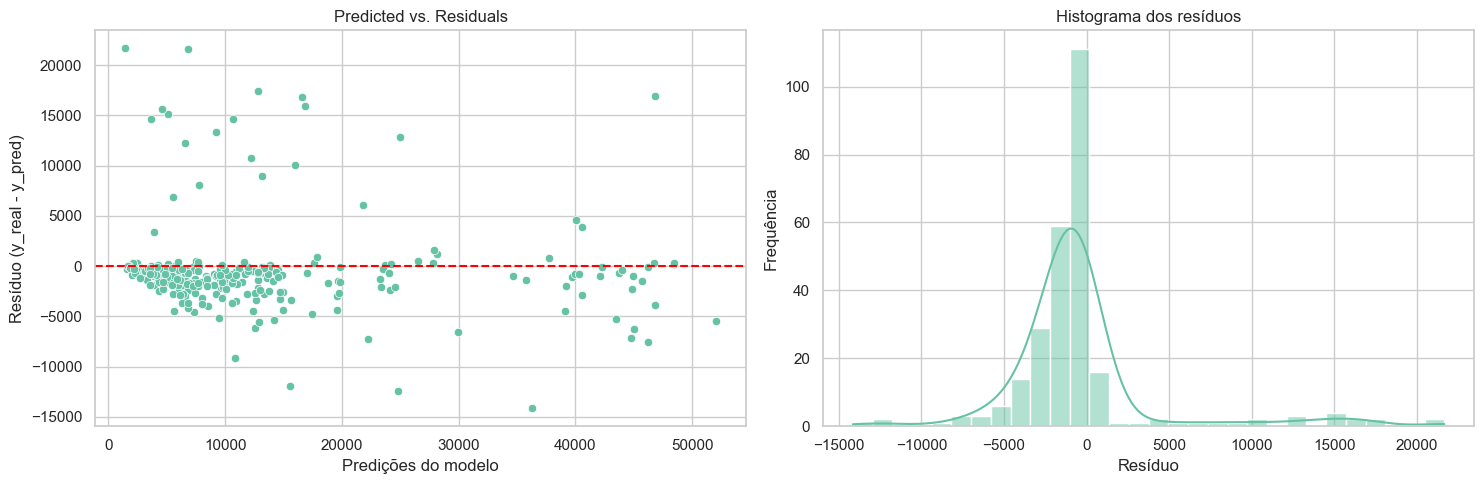

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=residual_analysis_df,
    x="y_pred",
    y="residual",
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Predicted vs. Residuals")
axes[0].set_xlabel("Predições do modelo")
axes[0].set_ylabel("Resíduo (y_real - y_pred)")

sns.histplot(
    data=residual_analysis_df,
    x="residual",
    kde=True,
    bins=30,
    ax=axes[1],
)
axes[1].set_title("Histograma dos resíduos")
axes[1].set_xlabel("Resíduo")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


### Maiores erros absolutos

Os cinco casos abaixo correspondem aos pacientes em que o modelo teve maior dificuldade. Esta inspeção ajuda a discutir se há perfis específicos, como fumantes com IMC elevado ou combinações raras de atributos, que continuam difíceis de modelar.


In [12]:
top_5_outliers = residual_analysis_df.sort_values(
    "abs_residual",
    ascending=False,
).head(5)

display(
    top_5_outliers[
        [
            "age",
            "sex",
            "bmi",
            "children",
            "smoker",
            "region",
            "y_real",
            "y_pred",
            "residual",
            "abs_residual",
        ]
    ]
)


,age,sex,bmi,children,smoker,region,y_real,y_pred,residual,abs_residual
430,19,male,33.1000,0,no,southwest,"23,082.9553","1,414.3875","21,668.5679","21,668.5679"
806,40,female,41.4200,1,no,northwest,"28,476.7350","6,845.3945","21,631.3405","21,631.3405"
115,60,male,28.5950,0,no,northeast,"30,259.9956","12,836.2723","17,423.7232","17,423.7232"
543,54,female,47.4100,0,yes,southeast,"63,770.4280","46,843.8252","16,926.6028","16,926.6028"
599,52,female,37.5250,2,no,northwest,"33,471.9719","16,594.9673","16,877.0046","16,877.0046"


## 10. Interpretação dos resultados

### Como ler os resultados

- Se a remoção de atributos provocar uma perda pequena em `MAE pooled` e `R2 pooled`, então a simplificação pode ser vantajosa.
- Se o boxplot ficar mais compacto após a remoção das variáveis, isso sugere redução de ruído entre os folds.
- Ao comparar Random Forest, Regressão Linear, Ridge e Lasso, podemos verificar como a regularização altera o compromisso entre simplicidade, estabilidade e precisão.

### Perguntas centrais deste estudo

- O **Lasso (Cenário F)** consegue superar a **Regressão Linear simples (Cenário C)**?
- O ganho do Lasso aproxima-se do desempenho do **Random Forest (Cenário A)** ou continua distante?
- Os coeficientes do Lasso indicam que variáveis como `sex` ou `region` podem ser descartadas sem perda relevante?
- A análise de resíduos do modelo campeão sugere erro puramente aleatório ou ainda há padrões sistemáticos ignorados?

### Interpretação esperada

Em problemas de custo médico, `smoker`, `age` e `bmi` concentram boa parte do sinal preditivo. A Regressão Linear simples tende a distribuir peso por mais variáveis, enquanto o Ridge estabiliza coeficientes e o Lasso pode efetivamente eliminar atributos fracos. O Random Forest, por sua flexibilidade, tende a capturar relações não lineares e geralmente serve como referência de desempenho superior, embora com maior custo computacional.
